# GCN4 IDR vs ADBD1 surface - `StructureSurface` version

The `structure_surface.py` analogue of `gcn4_abd1_v1.ipynb`. Both build a surface:IDR intermap
between the GCN4 N-terminal IDR and ADBD1, but `StructureSurface` first decomposes the
structure into folded domains and IDRs, identifies the *contiguous* folded surface, and scores
each surface residue against the contact footprint an IDR window of that length could actually
reach, rather than using a linear sequence window.

The map comes from `surface_vs_idr_matrix()`, which runs in **trans** (IDR is a separate
molecule) or **cis** (IDR is tethered, so only residues that can physically reach a given
surface residue contribute).

Section 5 covers the contact footprint - the part that makes a window-sized piece of surface,
rather than a single residue, the thing being scored.

In [2]:
from finches.frontend.mpipi_frontend import Mpipi_frontend
from finches.utils.structure_surface import StructureSurface

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

mf = Mpipi_frontend()

gcn4_ntd = 'MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNT'

ss = StructureSurface('ADBD1.pdb', mf)

# we recommend 31 for consistency with IDR:IDR intermaps
window_size = 31

## 1. What the structure was decomposed into

`StructureSurface` runs metapredict over the structure's own sequence, so residues predicted to
be disordered are not treated as folded-domain surface even though they are in the PDB.

In [3]:
print(f"residues in structure : {len(ss.residues)}")
print(f"folded               : {len(ss.folded_residues)}")
print(f"  of which surface   : {len(ss.surface_residues)}")
print(f"  of which buried    : {len(ss.folded_residues) - len(ss.surface_residues)}")
print(f"predicted IDR        : {len(ss.idr_residues)}")

for seg in ss.idr_segments:
    print(f"  IDR segment {seg['residues'][0].res_seq}-{seg['residues'][-1].res_seq}"
          f" (len {len(seg['residues'])})")

residues in structure : 81
folded               : 56
  of which surface   : 54
  of which buried    : 2
predicted IDR        : 25
  IDR segment 1-25 (len 25)


## 2. A plotting helper

`rows='all'` gives one row per residue in the structure, in sequence order, so the map can be
read straight down the chain. Surface residues and IDR residues are scored; **buried folded
residues are `np.nan` and are drawn as dark grey lines**, so they read as "not part of the
interacting surface" rather than as "non-interacting".

In [4]:
# this is the residue where the fd starts in its original protein
fd_offset = 158

def plot_intermap(X, keys, centres, title, vlim=None, cmap='PRGn', tic_frequency=10):
    """Draw a surface:IDR intermap; nan rows (buried residues) are greyed out."""

    if vlim is None:
        vlim = np.nanmax(np.abs(X))

    cm = plt.get_cmap(cmap).copy()
    cm.set_bad('0.30')   # buried / unscorable residues -> dark grey

    figure(None, (7, 3.2), dpi=350)
    plt.imshow(np.ma.masked_invalid(X),
               extent=[centres[0], centres[-1], 0, len(keys)],
               origin='lower', aspect='auto', vmin=-vlim, vmax=vlim, cmap=cm)
    ax = plt.gca()

    row_positions = np.arange(0, len(keys), 5) + 0.5
    ax.set_yticks(row_positions, [keys[int(p)][1] + fd_offset for p in row_positions])

    ax.set_xticks(np.arange(centres[0], centres[-1], tic_frequency))
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('GCN4 IDR residue')
    ax.set_ylabel('ADBD1 residue')
    ax.set_title(title, fontsize=8)

    plt.colorbar()
    plt.tight_layout()
    return ax

## 3. The trans intermap, over the whole chain

Every residue gets a row. Grey rows are buried folded residues, which have no exposed surface
to interact with. The IDR residues of ADBD1 itself (1-25) are scored too - they are disordered,
so they can interact, and they take their weighting context from the linear sequence rather
than from a surface patch.

map shape (all residues x IDR windows): (81, 206)
greyed-out (buried) rows: 2
value range: -24.659 to +19.702


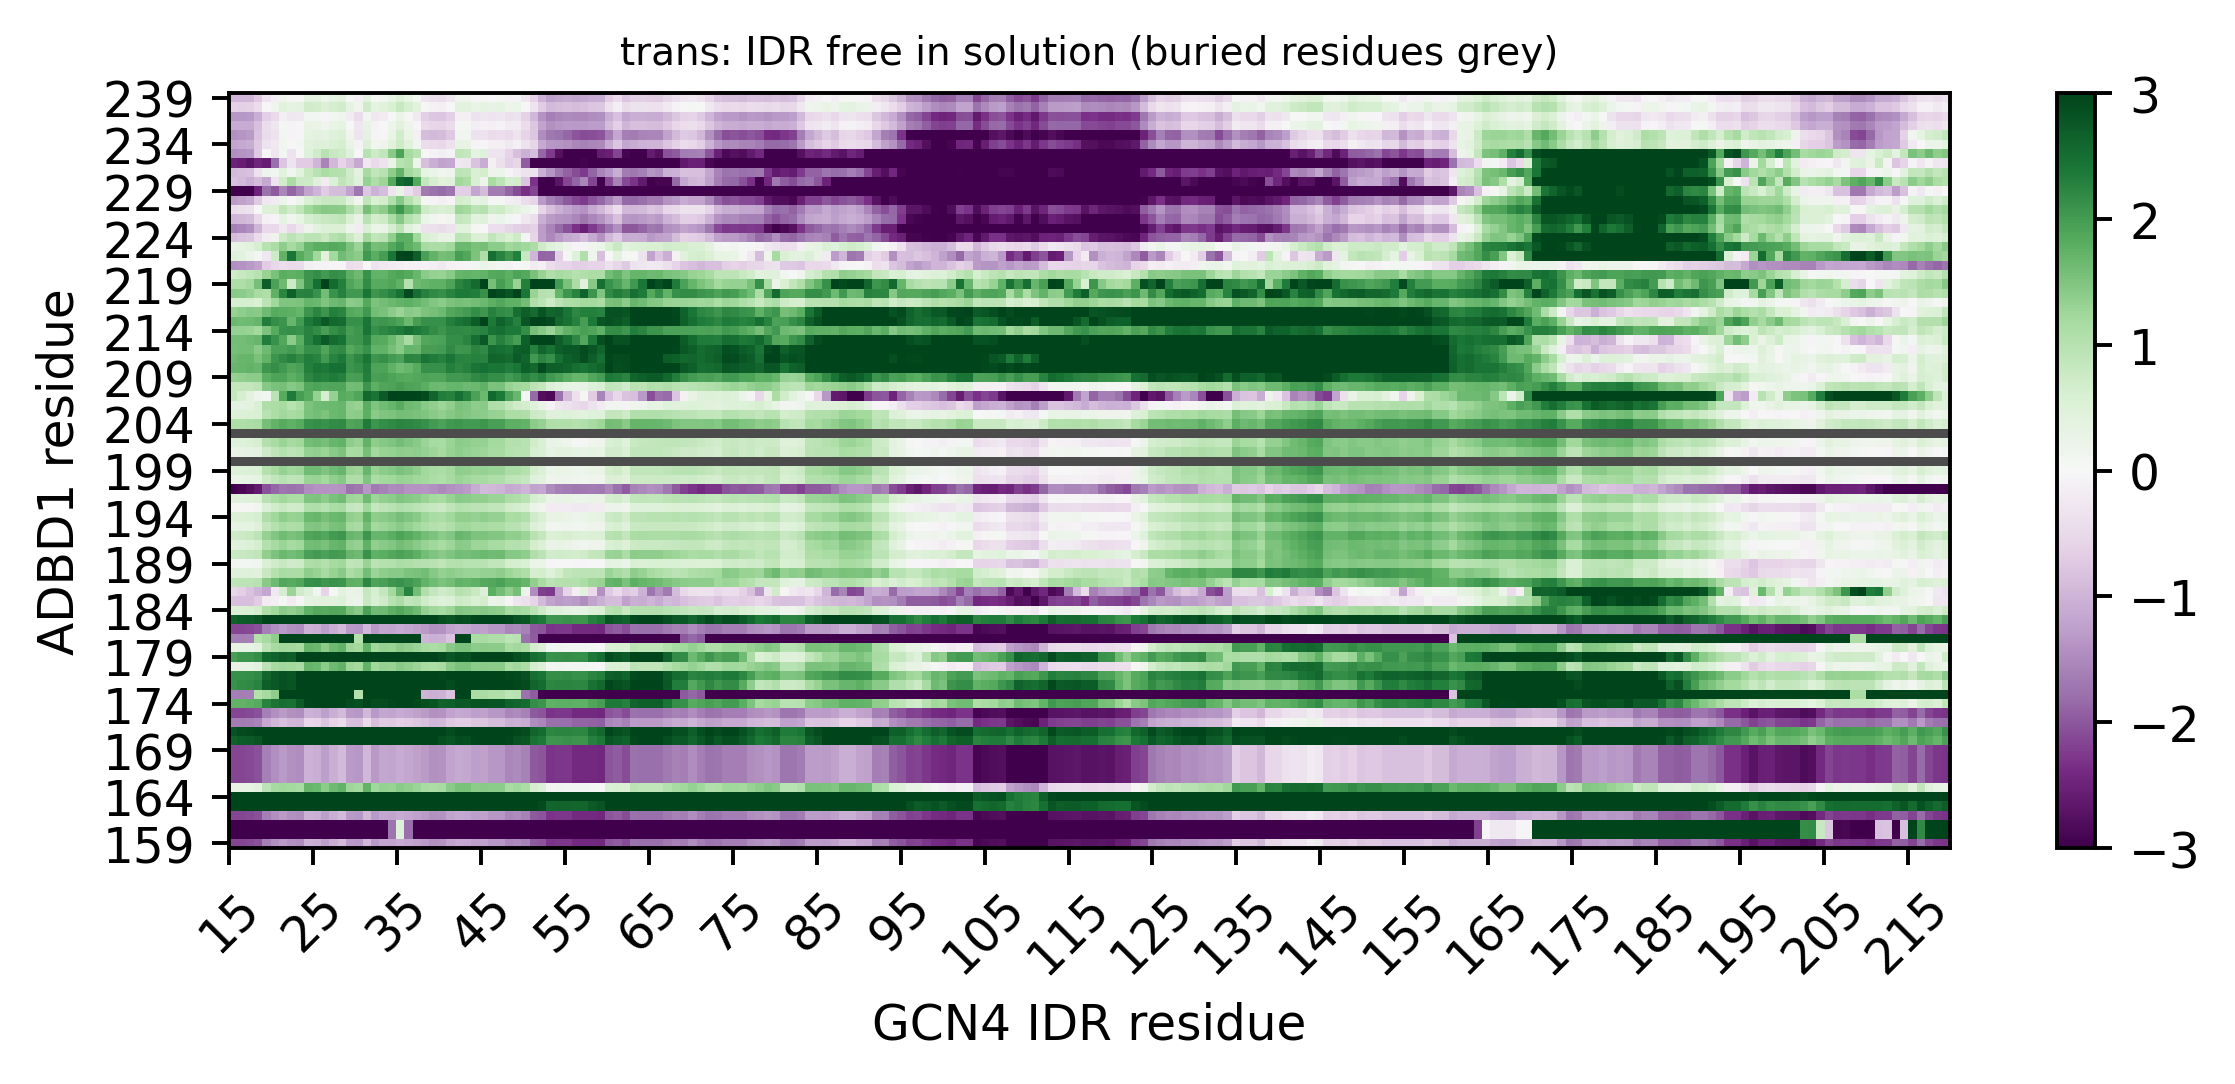

In [5]:
X_trans, keys, centres = ss.surface_vs_idr_matrix(
    gcn4_ntd, window_size=window_size, rows='all')

print(f"map shape (all residues x IDR windows): {X_trans.shape}")
print(f"greyed-out (buried) rows: {np.isnan(X_trans).all(axis=1).sum()}")
print(f"value range: {np.nanmin(X_trans):+.3f} to {np.nanmax(X_trans):+.3f}")

vlim = np.nanmax(np.abs(X_trans))
plot_intermap(X_trans, keys, centres, 'trans: IDR free in solution (buried residues grey)', vlim=3)
plt.show()

## 4. The cis intermap

`idr_tether()` resolves the anchor and which terminus of the IDR is attached, straight from the
decomposition. ADBD1's one IDR segment (1-25) is anchored at residue 26, so the IDR runs off the
N-terminal side of the domain and it is the IDR's **C-terminus** that is tethered.

The tether reach is `R(s) = reach_b * s**reach_nu` Angstrom, with `s` the contour separation from
the tether, floored by the contact shell. As with the footprint, `R(s)` is a *mean* end-to-end
distance rather than a hard limit, so an IDR position is attenuated by
`exp(-3 d**2 / (2 R**2))` in how far it has to stray from the anchor - it fades out with distance
instead of switching off at a boundary. A hard cutoff would draw a sharp ring across the map of
any domain large enough for the constraint to bite.

anchor = (0, 26), tethered terminus = C


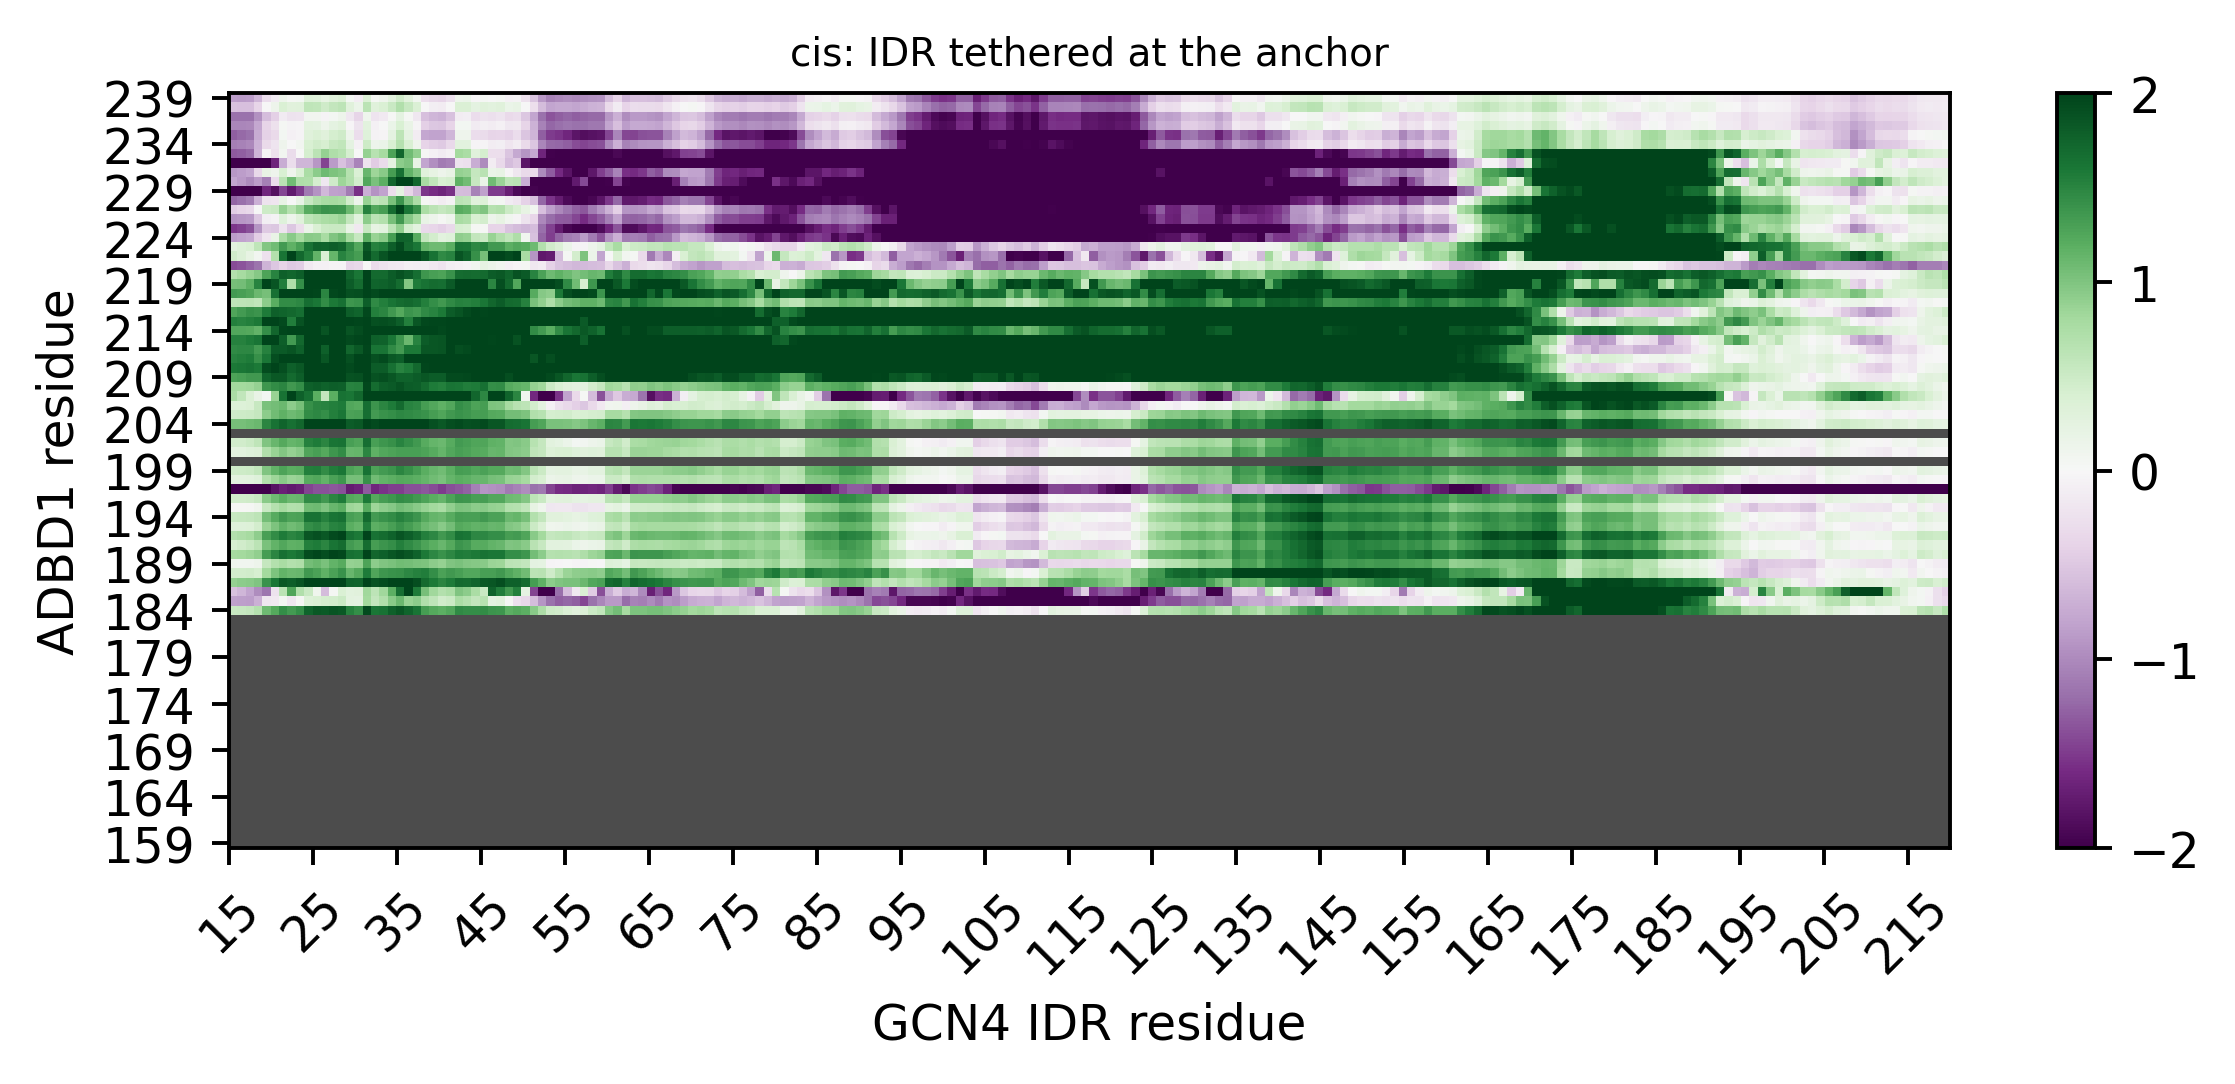

mean |cis - trans| = 0.1725, max = 3.0417


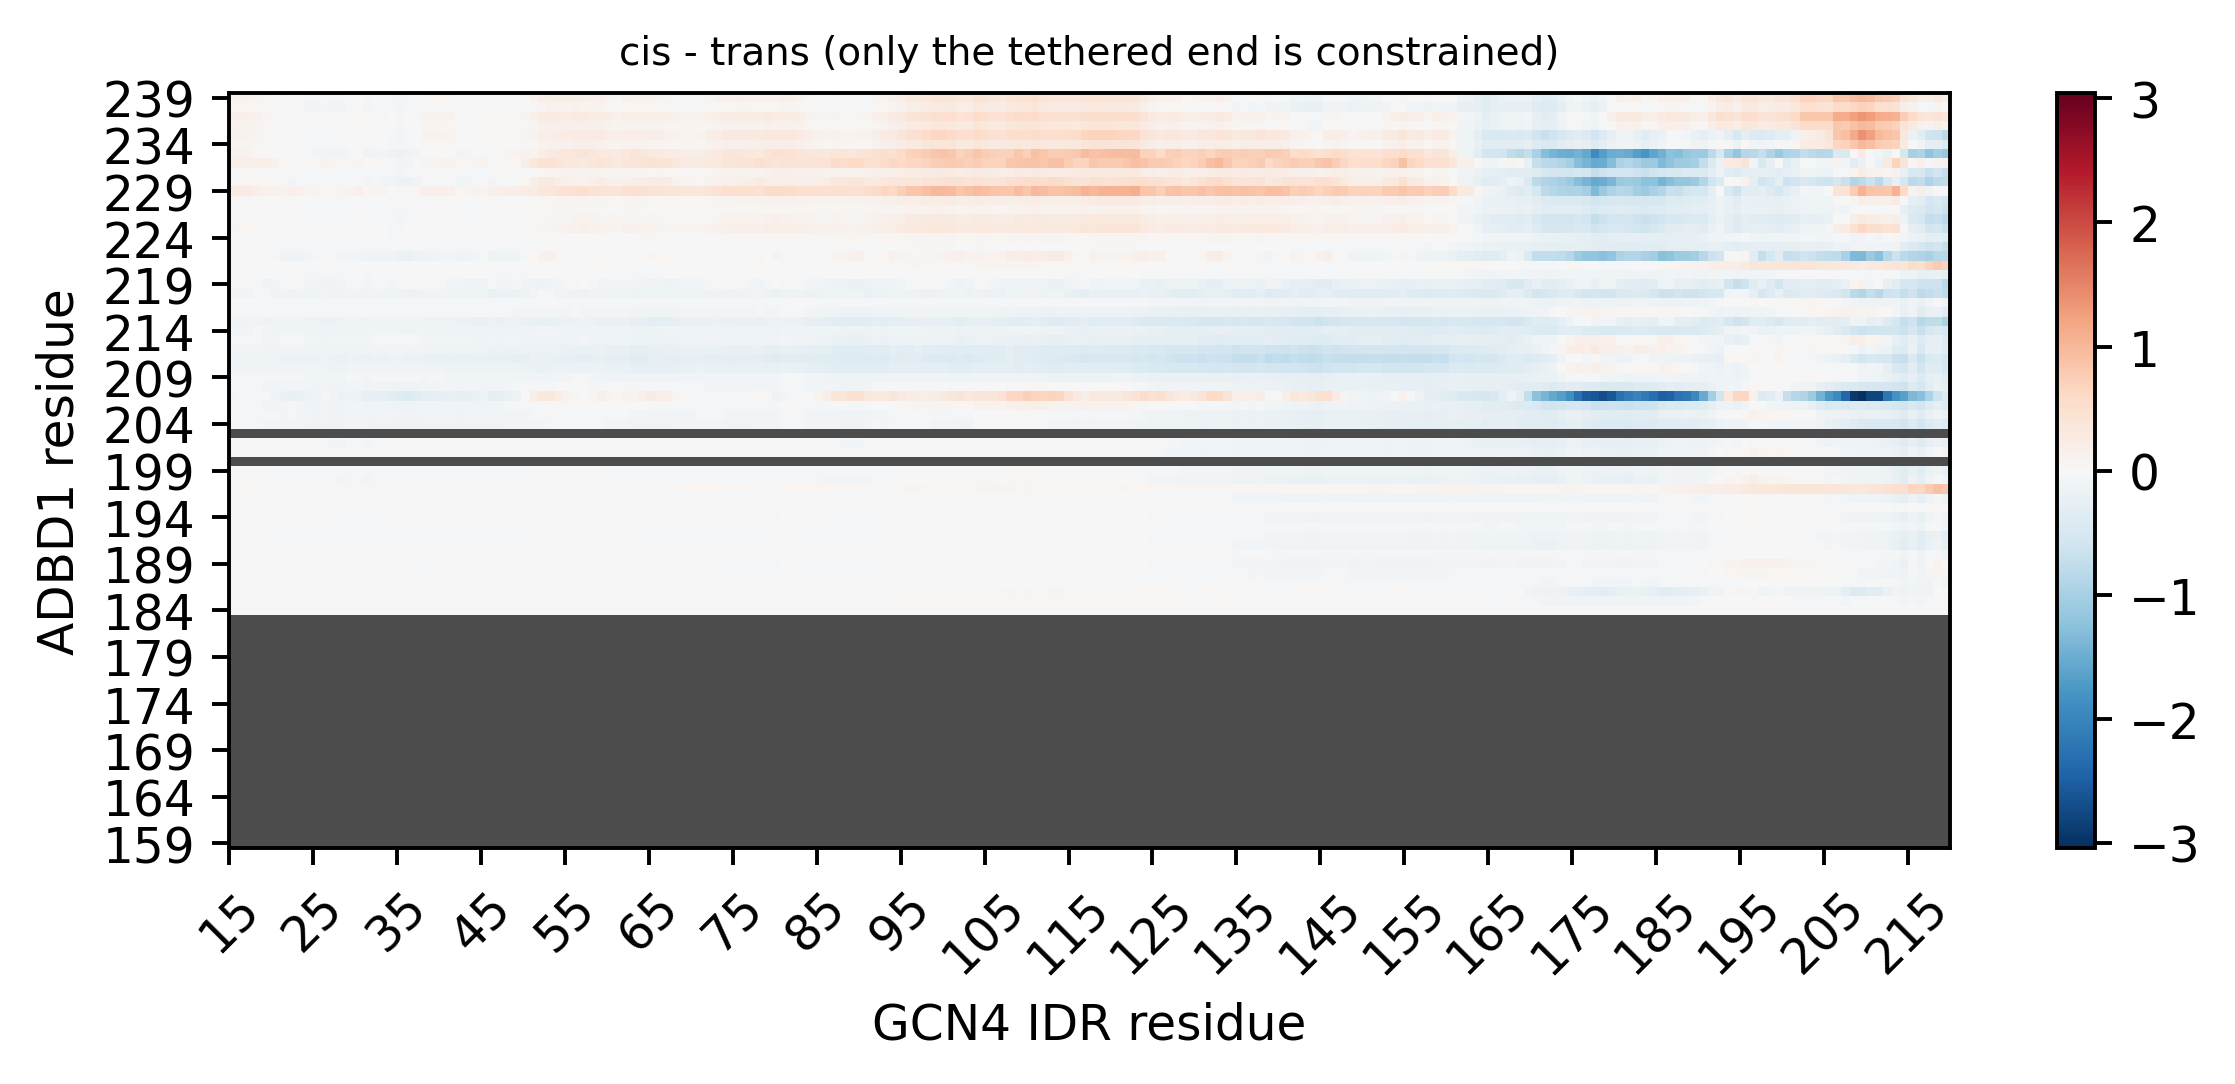

In [6]:
anchor, tether = ss.idr_tether(0)
print(f"anchor = {anchor}, tethered terminus = {tether}")

X_cis, _, _ = ss.surface_vs_idr_matrix(
    gcn4_ntd, window_size=window_size, rows='all', anchor=anchor, tether=tether)

plot_intermap(X_cis, keys, centres, 'cis: IDR tethered at the anchor', vlim=2)
plt.show()

diff = X_cis - X_trans
print(f"mean |cis - trans| = {np.nanmean(np.abs(diff)):.4f}, max = {np.nanmax(np.abs(diff)):.4f}")
plot_intermap(diff, keys, centres, 'cis - trans (only the tethered end is constrained)',
              cmap='RdBu_r')
plt.show()

The difference is concentrated at the far right - the C-terminal end of the IDR, nearest the
tether, whose residues are too close to the anchor to reach the far side of the domain. For a
domain this small a 236-residue IDR otherwise reaches everywhere, so cis and trans nearly agree.
Shorten the reach and the constraint bites properly:

with reach_b=1.0, signal retained relative to trans:
  median  24.4%   <1% retained:  0.0% of surface rows   >90% retained: 16.7%
  correlation of retained signal with distance from the anchor: -0.67
  rows at intermediate attenuation (1-90%): 45 - a hard cutoff would leave none


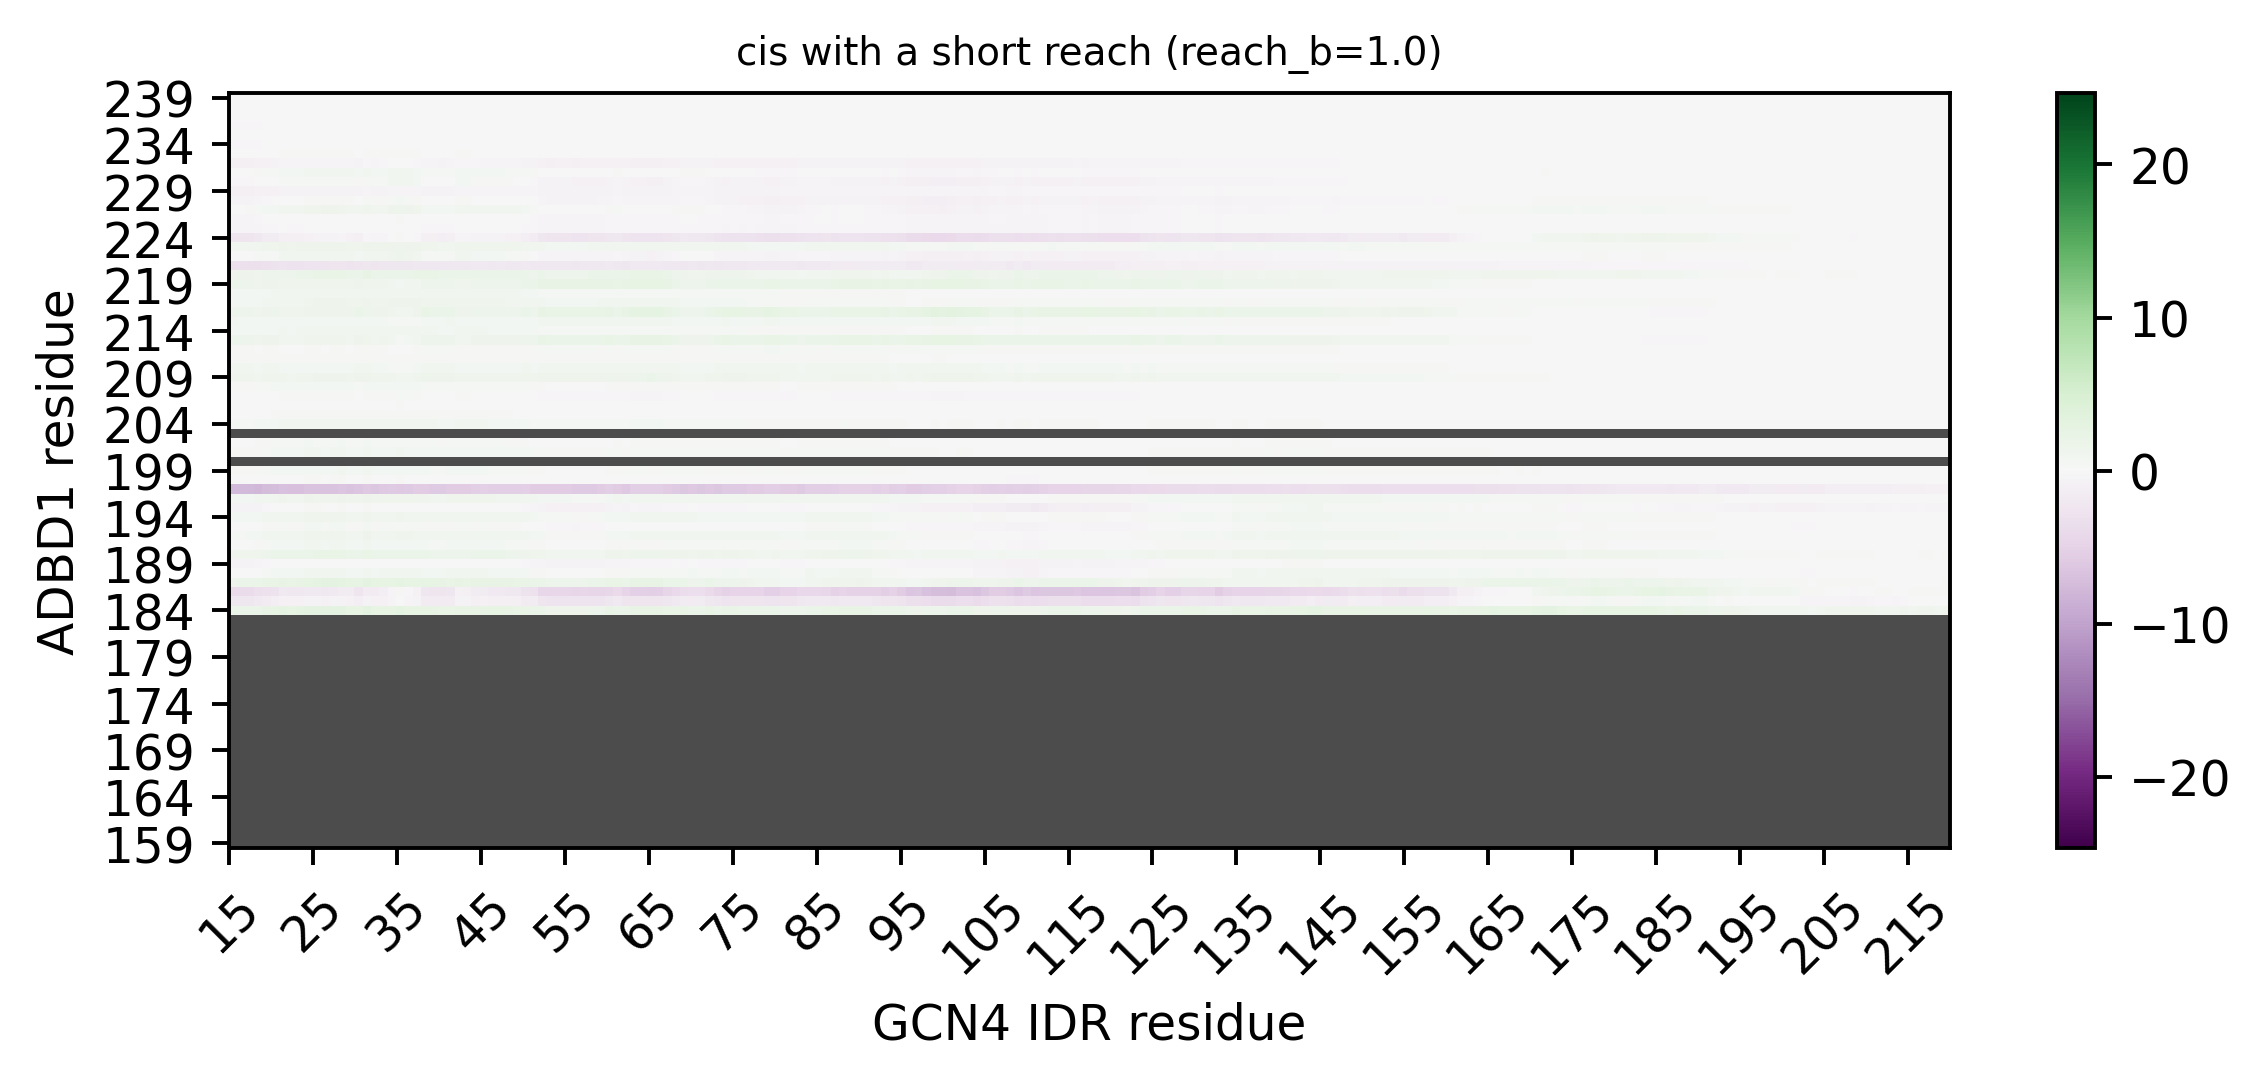

In [7]:
X_tight, _, _ = ss.surface_vs_idr_matrix(
    gcn4_ntd, window_size=window_size, rows='all',
    anchor=anchor, tether=tether, reach_b=1.0)

# with a soft gate nothing is exactly zero, so measure how much signal survives
surf_set = {r.key for r in ss.surface_residues}
si = [i for i, k in enumerate(keys) if k in surf_set]
kept = np.mean(np.abs(X_tight[si]), axis=1) / np.mean(np.abs(X_trans[si]), axis=1)

apos = ss._anchor_position(anchor)
dist = np.array([np.linalg.norm(apos - ss.get_residue(*keys[i]).position) for i in si])

print(f'with reach_b=1.0, signal retained relative to trans:')
print(f'  median {100*np.median(kept):5.1f}%   '
      f'<1% retained: {100*np.mean(kept < 0.01):4.1f}% of surface rows   '
      f'>90% retained: {100*np.mean(kept > 0.90):4.1f}%')
print(f'  correlation of retained signal with distance from the anchor: '
      f'{np.corrcoef(dist, kept)[0, 1]:+.2f}')
print(f'  rows at intermediate attenuation (1-90%): {np.sum((kept > 0.01) & (kept < 0.90))} '
      f'- a hard cutoff would leave none')

plot_intermap(X_tight, keys, centres, 'cis with a short reach (reach_b=1.0)', vlim=vlim)
plt.show()

## 5. The contact footprint

A 31-residue window laid over the surface does not touch one residue, it touches a patch of
them - and how many depends on how long the window is. `surface_vs_idr_matrix()` models this
explicitly.

The window's centre residue is treated as pinned over the row's residue. The residue `k` steps
along the chain then sits typically `R(|k|) = 5.0 * |k|**0.54` Angstrom away, so it contacts
surface at roughly that *geodesic* (over-the-surface) distance from the pinned point. The centre
is seen by every residue in the window, distant surface only by the residues near the window's
ends.

Two details stop this behaving as a point contact:

- `R(|k|)` is the **mean** end-to-end distance of a `|k|`-residue segment, not a hard limit, so
  contact weight falls off as `exp(-3 d**2 / (2 R**2))` rather than switching off at a cutoff.
  A top-hat mask makes a residue flip in and out of the footprint as the pinned point moves by an
  Angstrom, which puts steps into the map that the structure does not have.
- the reach is floored at `contact_radius` (default 6 A) via `R_eff = sqrt(contact_radius**2 +
  R**2)`, because even the pinned residue has a side chain and touches a *shell* of surface.

The weighting that gives the centre residue its prominence is **derived from the polymer model**,
not tuned - a surface Arg surrounded by Ser keeps its weight because the geometry says every
window residue can touch it.

In [8]:
D = ss.surface_distance
skeys = [r.key for r in ss.surface_residues]

print('footprint size vs window length (residues within the k=half contact shell):')
for W in [5, 11, 21, 31, 51]:
    R = np.hypot(ss.reach_radius(W // 2), 6.0)
    sizes = [sum(1 for kk, v in D[k].items() if v <= R) for k in skeys]
    print(f'  W={W:>3}  radius {R:5.1f} A  ->  {np.mean(sizes):5.1f} surface residues '
          f'({100*np.mean(sizes)/len(skeys):3.0f}% of the surface)')

# how much of a row's weight each surface residue carries, by geodesic rank from the centre
half = window_size // 2
reach = np.hypot(ss.reach_radius(np.arange(half + 1)), 6.0)
mult = np.full(half + 1, 2.0)
mult[0] = 1.0

shares = []
for k in skeys:
    _, dists = ss._footprint_order(k)
    Wm = np.exp(-1.5 * (dists[None, :] / reach[:, None]) ** 2)
    Wm /= Wm.sum(axis=1, keepdims=True)
    w = (Wm * mult[:, None]).sum(axis=0)
    shares.append(w / w.sum())

n = min(len(s) for s in shares)
mean_share = np.mean([s[:n] for s in shares], axis=0)
print()
print('share of a row carried by each surface residue, by distance rank from the centre:')
for r in range(6):
    print(f'  rank {r} {"(the residue itself)" if r == 0 else "":22s} {100*mean_share[r]:5.1f}%')
print(f'  ranks 0-2 combined                          {100*mean_share[:3].sum():5.1f}%')

footprint size vs window length (residues within the k=half contact shell):
  W=  5  radius   9.4 A  ->    5.3 surface residues ( 10% of the surface)
  W= 11  radius  13.3 A  ->    8.4 surface residues ( 16% of the surface)
  W= 21  radius  18.3 A  ->   14.9 surface residues ( 28% of the surface)
  W= 31  radius  22.4 A  ->   22.2 surface residues ( 41% of the surface)
  W= 51  radius  29.1 A  ->   32.1 surface residues ( 59% of the surface)

share of a row carried by each surface residue, by distance rank from the centre:
  rank 0 (the residue itself)    18.3%
  rank 1                         11.9%
  rank 2                         10.3%
  rank 3                          8.7%
  rank 4                          7.0%
  rank 5                          5.6%
  ranks 0-2 combined                           40.5%


### Units: comparable with an IDR:IDR intermap

Each cell is a sum over the IDR window of a mean over the surface residues each IDR residue can
reach - the same form as a FINCHES IDR:IDR cell (a sum over one window, a mean over the other).
That is what makes the numbers comparable, and it is asserted in the test suite: with the
weighting terms off, a patch-only cell reproduces
`calculate_epsilon_value(window, patch)` to machine precision.

In [9]:
B = mf.intermolecular_idr_matrix(gcn4_ntd, gcn4_ntd, window_size=window_size)[0][0]

def pct(a):
    return np.nanpercentile(a, [1, 50, 99])

# compare surface rows only: an IDR row is a single residue against a window, which is
# a legitimate but different object and has a much wider spread
X_surf, surf_keys, _ = ss.surface_vs_idr_matrix(gcn4_ntd, window_size=window_size)

print(f'IDR:IDR      p1/median/p99 = {np.round(pct(B), 2)}   spread {pct(B)[2]-pct(B)[0]:.2f}')
print(f'surface:IDR  p1/median/p99 = {np.round(pct(X_surf), 2)}   spread {pct(X_surf)[2]-pct(X_surf)[0]:.2f}')
print(f'spread ratio = {(pct(X_surf)[2]-pct(X_surf)[0])/(pct(B)[2]-pct(B)[0]):.2f}x')

# does the surface now behave as a smooth object?
def neighbour_correlation(X, keys):
    row_of = {k: i for i, k in enumerate(keys)}
    ok = [k for k in keys if np.all(np.isfinite(X[row_of[k]]))]
    def corr(a, b):
        return np.corrcoef(a, b)[0, 1]
    sp = [corr(X[row_of[k]], X[row_of[nb]])
          for k in ok for nb in ss.surface_neighbours.get(k, []) if nb in row_of]
    rng = np.random.default_rng(0)
    idx = [row_of[k] for k in ok]
    rd = [corr(X[i], X[j]) for i, j in rng.choice(idx, (400, 2)) if i != j]
    return np.mean(sp), np.mean(rd)

sp, rd = neighbour_correlation(X_surf, surf_keys)
print(f'\nspatial smoothness: neighbours {sp:+.3f} vs random {rd:+.3f} (gap {sp-rd:+.3f})')

aas = [ss.get_residue(*k).one_letter for k in surf_keys]
q = [i for i, a in enumerate(aas) if a == 'Q']
print(f'spread across the {len(q)} surface Gln residues: {np.ptp(X_surf[q].mean(axis=1)):.2f} '
      f'(environment matters, no dilution)')

IDR:IDR      p1/median/p99 = [-2.26  2.04  6.47]   spread 8.72
surface:IDR  p1/median/p99 = [-4.92  0.7   4.36]   spread 9.28
spread ratio = 1.06x

spatial smoothness: neighbours +0.820 vs random +0.431 (gap +0.388)
spread across the 13 surface Gln residues: 3.32 (environment matters, no dilution)


### What the footprint changes

Side by side on a shared colour scale. On the left `use_footprint=False`, where every IDR
residue is averaged over the same ~5-residue contiguous-surface patch. On the right the default,
where the surface each IDR residue sees is set by how far along the window it sits.

The difference is not simply that one is smoother. Under `use_footprint=False` every IDR residue
averages over the same ~5 residues, so neighbouring rows share most of their content *and* the
centre residue is diluted to a fifth of every cell. Under the footprint the centre is seen by all
31 residues of the window while distant surface is seen only by the residues near the window
ends, so the centre keeps its weight - that is the anti-dilution property - while the map also
reaches out to surface the patch could not see.

The net effect is that the centre-specific signal survives instead of being averaged away, while
individual cells move substantially wherever a residue's wider surroundings differ from its
immediate patch. Smoothness across neighbouring rows is a separate question, set by
`contact_radius` - see below.

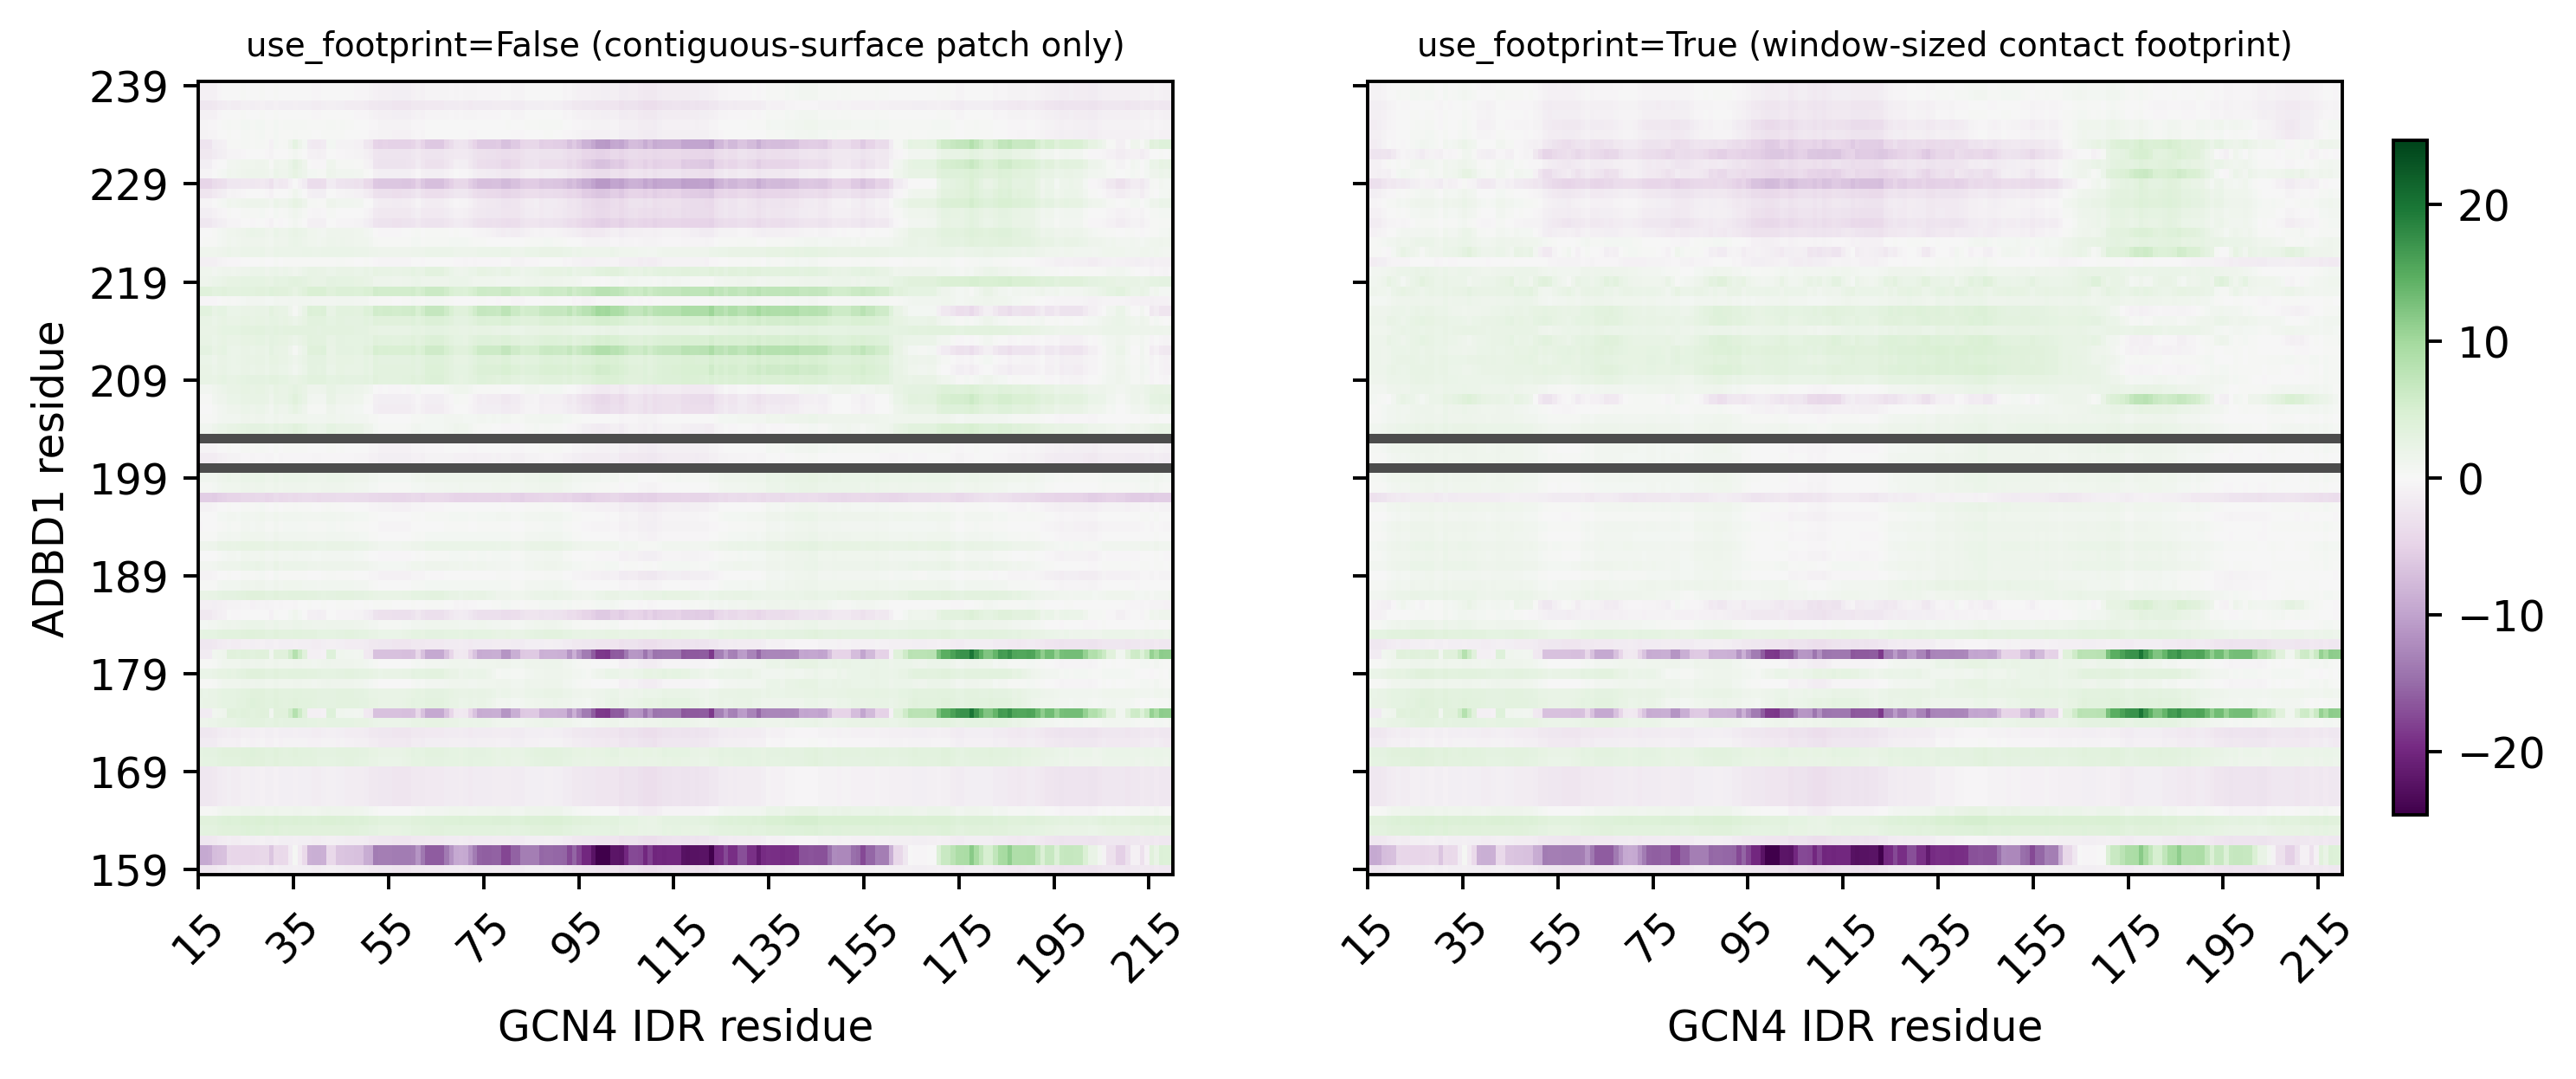

surface rows, patch only : range  -10.94 .. +10.37
surface rows, footprint  : range   -7.58 ..  +7.90
mean |difference| = 1.00, max = 7.31
IDR rows identical either way: True (they have no surface footprint)


In [10]:
X_patch_only, _, _ = ss.surface_vs_idr_matrix(
    gcn4_ntd, window_size=window_size, rows='all', use_footprint=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), dpi=350, sharey=True)

cm = plt.get_cmap('PRGn').copy()
cm.set_bad('0.30')
lim = np.nanmax(np.abs(X_trans))

for ax, M, title in zip(axes,
                        [X_patch_only, X_trans],
                        ['use_footprint=False (contiguous-surface patch only)',
                         'use_footprint=True (window-sized contact footprint)']):
    im = ax.imshow(np.ma.masked_invalid(M),
                   extent=[centres[0], centres[-1], 0, len(keys)],
                   origin='lower', aspect='auto', vmin=-lim, vmax=lim, cmap=cm)
    ax.set_xticks(np.arange(centres[0], centres[-1], 20))
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('GCN4 IDR residue')
    ax.set_title(title, fontsize=8)

rws = np.arange(0, len(keys), 10) + 0.5
axes[0].set_yticks(rws, [keys[int(t)][1] + fd_offset for t in rws])
axes[0].set_ylabel('ADBD1 residue')

fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
plt.show()

# compare surface rows only: IDR rows have no footprint and are identical either way,
# and they dominate the overall min/max
surf_set = {r.key for r in ss.surface_residues}
si = [i for i, k in enumerate(keys) if k in surf_set]

print(f'surface rows, patch only : range {X_patch_only[si].min():+7.2f} .. {X_patch_only[si].max():+6.2f}')
print(f'surface rows, footprint  : range {X_trans[si].min():+7.2f} .. {X_trans[si].max():+6.2f}')
print(f'mean |difference| = {np.abs(X_patch_only[si] - X_trans[si]).mean():.2f}, '
      f'max = {np.abs(X_patch_only[si] - X_trans[si]).max():.2f}')

idr_set = {r.key for r in ss.idr_residues}
ii = [i for i, k in enumerate(keys) if k in idr_set]
print(f'IDR rows identical either way: {np.allclose(X_patch_only[ii], X_trans[ii])} '
      f'(they have no surface footprint)')

### Why the map is spatially smooth

Two surface residues that touch each other are seen by almost the same window, so their rows
ought to agree - a map where neighbouring rows jump around is reporting geometry the structure
does not have.

The `contact_radius` floor is what delivers this. With `contact_radius=0` the window's centre
residue contacts a single point, that one residue carries ~20% of every cell on its own, and the
map is visibly striped. At the default 6 A - the median nearest-neighbour spacing on this
surface, i.e. one shell of touching residues - neighbouring rows agree while the centre residue
still carries its weight.

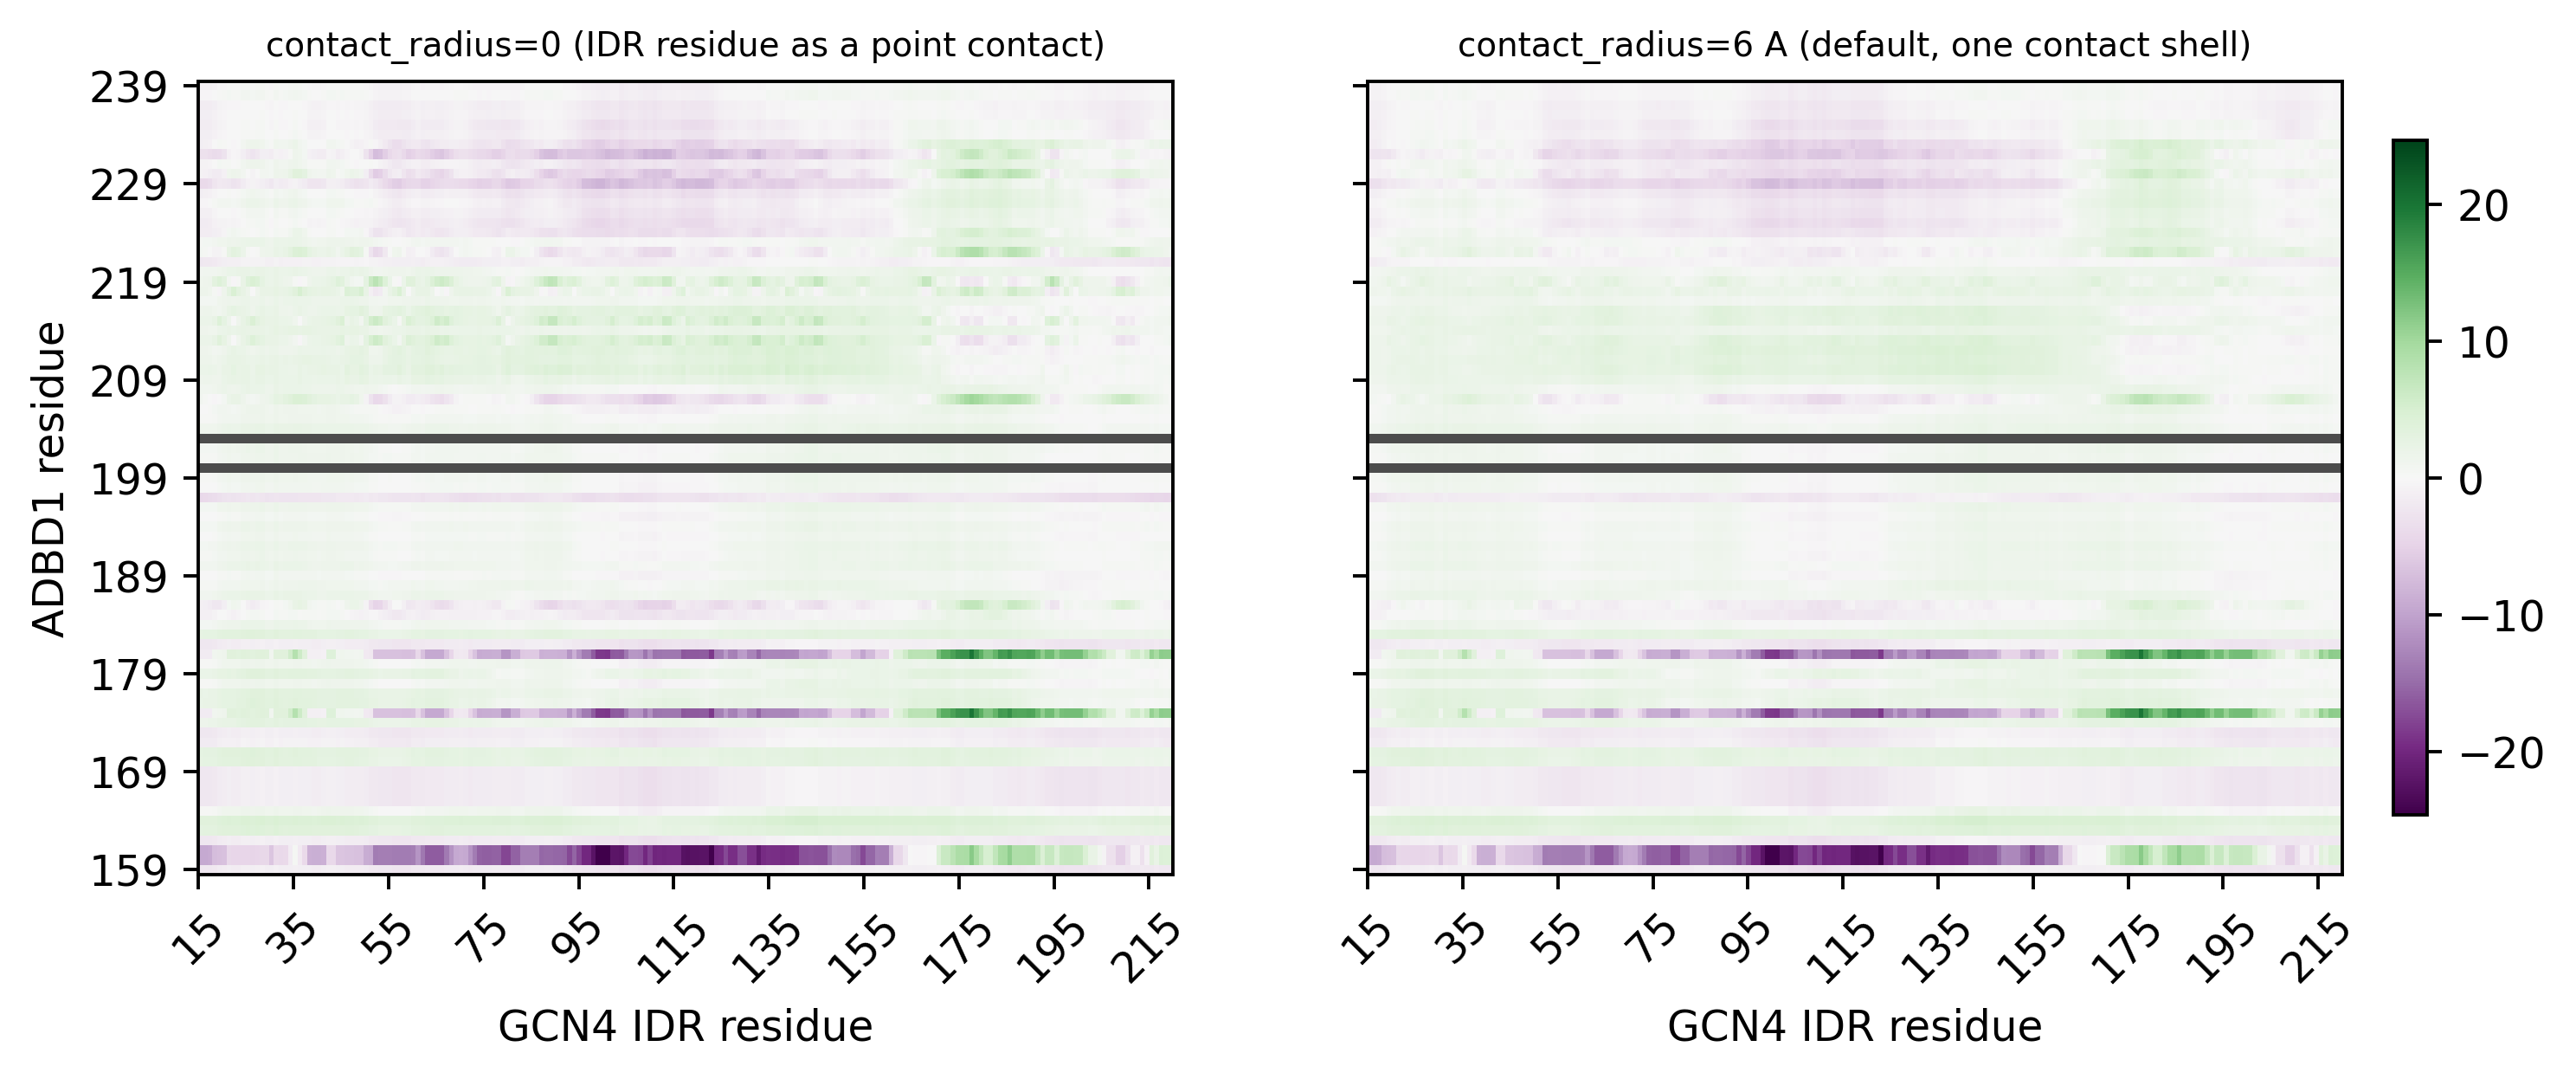

how much two surface residues disagree, by how far apart they are:
  contact_radius=0   touching (<8 A) 1.12   distant (>=8 A) 2.12   ratio 0.53
  contact_radius=6   touching (<8 A) 0.69   distant (>=8 A) 1.82   ratio 0.38

spread across the 13 surface Q residues: 3.32 (matrix std 1.80) - environment still separates identical residues



spread across the 13 surface Q residues: 3.32 (matrix std 1.80) - environment still separates identical residues


In [11]:
X_point, _, _ = ss.surface_vs_idr_matrix(
    gcn4_ntd, window_size=window_size, rows='all', contact_radius=0.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), dpi=350, sharey=True)

cm = plt.get_cmap('PRGn').copy()
cm.set_bad('0.30')
lim = np.nanmax(np.abs(X_trans))

for ax, M, title in zip(axes,
                        [X_point, X_trans],
                        ['contact_radius=0 (IDR residue as a point contact)',
                         'contact_radius=6 A (default, one contact shell)']):
    im = ax.imshow(np.ma.masked_invalid(M),
                   extent=[centres[0], centres[-1], 0, len(keys)],
                   origin='lower', aspect='auto', vmin=-lim, vmax=lim, cmap=cm)
    ax.set_xticks(np.arange(centres[0], centres[-1], 20))
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('GCN4 IDR residue')
    ax.set_title(title, fontsize=8)

rws = np.arange(0, len(keys), 10) + 0.5
axes[0].set_yticks(rws, [keys[int(t)][1] + fd_offset for t in rws])
axes[0].set_ylabel('ADBD1 residue')

fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
plt.show()


def row_disagreement(M, lo, hi):
    # mean |row_a - row_b| for surface pairs a geodesic distance [lo, hi) apart
    surf = ss.surface_residues
    out = [np.mean(np.abs(M[a] - M[b]))
           for a in range(len(surf)) for b in range(a + 1, len(surf))
           if lo <= D.get(surf[a].key, {}).get(surf[b].key, np.inf) < hi]
    return np.mean(out)


X_pt_s, _, _ = ss.surface_vs_idr_matrix(gcn4_ntd, window_size=window_size, contact_radius=0.0)
X_sm_s, _, _ = ss.surface_vs_idr_matrix(gcn4_ntd, window_size=window_size)

print('how much two surface residues disagree, by how far apart they are:')
for label, M in [('contact_radius=0', X_pt_s), ('contact_radius=6', X_sm_s)]:
    near = row_disagreement(M, 0, 8)
    far = row_disagreement(M, 8, np.inf)
    print(f'  {label:18s} touching (<8 A) {near:.2f}   distant (>=8 A) {far:.2f}   '
          f'ratio {near/far:.2f}')

# the smoothing must not wash out the identity of the residue each row is about
aas = np.array([ss.get_residue(*k).one_letter for k in [r.key for r in ss.surface_residues]])
common = max(set(aas), key=list(aas).count)
idx = np.where(aas == common)[0]
print(f'\nspread across the {len(idx)} surface {common} residues: '
      f'{np.ptp(X_sm_s[idx].mean(axis=1)):.2f} '
      f'(matrix std {X_sm_s.std():.2f}) - environment still separates identical residues')

## 6. On dynamic range

With the footprint aggregation the values now sit on the same scale as an IDR:IDR intermap
(spread ratio close to 1 above), so the earlier concern about a compressed range is resolved -
it was a normalisation artefact of averaging a single residue over a window.

What remains, and is physical rather than an artefact, is cancellation: attractive and repulsive
contacts partly offset inside each window, so the magnitude is smaller than the mean absolute
contact energy. How much varies a lot between surface regions. That is a genuine property of
challenging a mixed-charge surface with a mixed-charge IDR, and it is why the map is most
informative about *contrast between regions* rather than about absolute values.

## 7. How this differs from the `FoldedDomain` intermap

**The rows are a different set of residues.** `FoldedDomain` treats all 81 residues in the PDB
as folded domain. `StructureSurface` predicts disorder first, scores the IDR residues with
linear-sequence context, and greys out only the buried folded residues.

**The values are now on the FINCHES epsilon scale**, comparable with an IDR:IDR intermap, which
was not true of the earlier per-residue-mean version. `FoldedDomain` sums over a patch laid out
as a pseudo-sequence and is not directly comparable to either. Within any map, negative (purple)
is attractive and positive (green) is repulsive.

**The local environment is defined differently.** For the surface side, `StructureSurface`
averages the base energy over the contiguous-surface patch - the residues a partner chain would
really encounter together - and weights it by the patch's charge and aliphatic composition,
rather than laying the patch out as a pseudo-sequence as `FoldedDomain` does.

One further detail: the IDR-side weighting is computed once over the full IDR sequence rather
than separately within each window, so residues near a window boundary keep their true sequence
neighbours rather than being truncated.